# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PrishaSolanki-coder/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

I checked the distributions of freshness, visibility, and search position. Impressions and search volume are expected to be right-skewed, so I also inspect their log-transformed distributions. These fields have heavy tails, meaning a relatively small number of pages have much larger values than most pages.

Dataset shape: (30000, 45)

Distribution summary:
                          count         mean           std  min     25%  \
days_since_last_update  30000.0    46.098300     42.078709  1.0    20.0   
impressions_90d         30000.0  5200.366300  16838.019547  1.0    81.0   
avg_position            30000.0    16.342380     15.216790  0.0     6.2   
search_volume           27532.0   158.882391   1518.270825  0.0     0.0   
word_count              22301.0  3107.760325   1452.382598  8.0  2413.0   

                           50%      75%      90%        99%       max  
days_since_last_update    20.0   104.00    104.0    106.000     373.0  
impressions_90d          731.0  3615.25  12136.4  73505.830  517715.0  
avg_position              10.8    22.30     36.8     69.901     245.0  
search_volume             10.0    20.00    110.0   2900.000   74000.0  
word_count              2877.0  3666.00   5327.0   7292.000    9546.0  


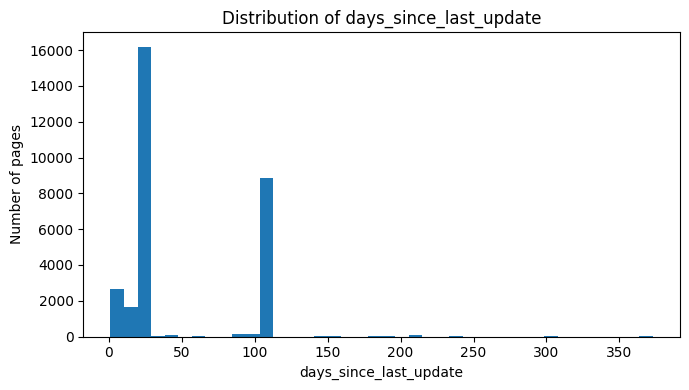

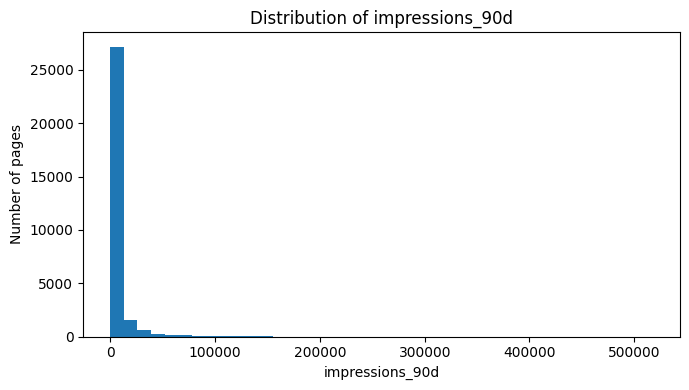

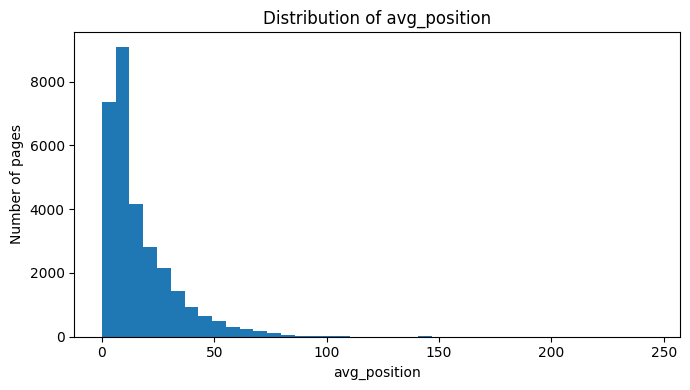

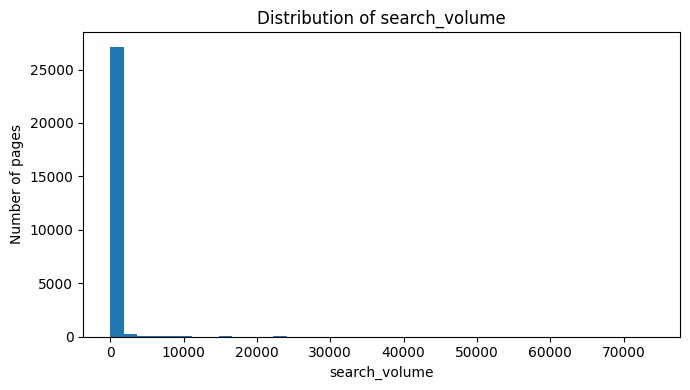

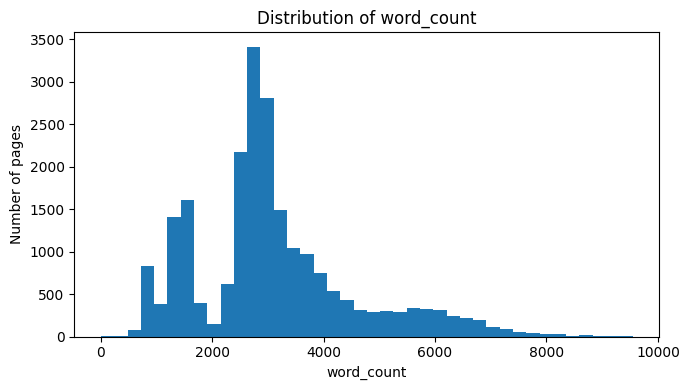

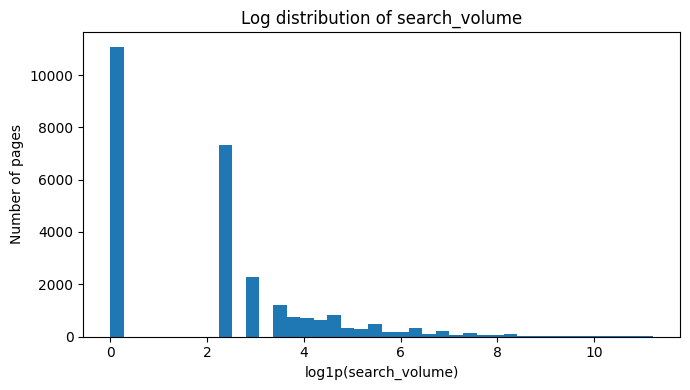

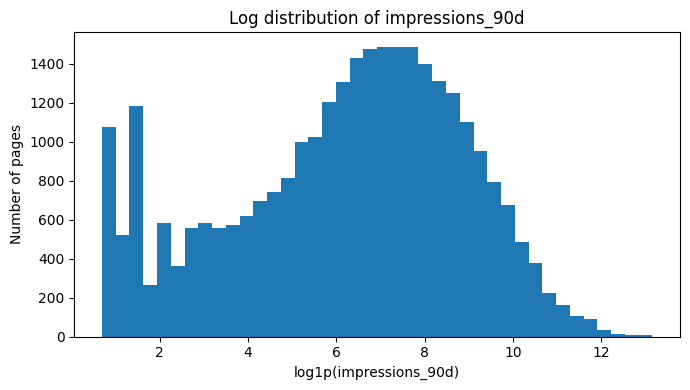

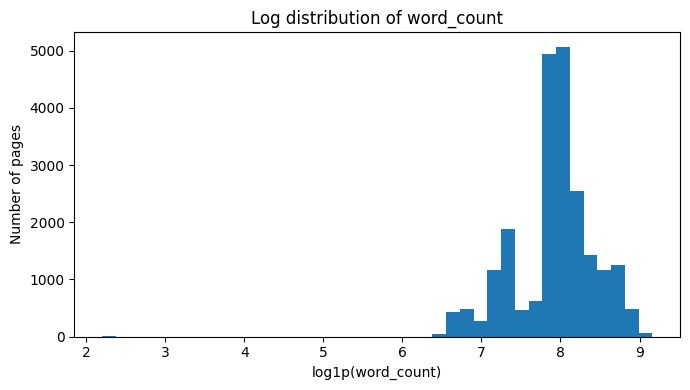

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load FlyRank dataset
url = "https://raw.githubusercontent.com/PrishaSolanki-coder/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

# Create label
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

# Key fields for signal audit
signal_cols = [
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "search_volume",
    "word_count"
]

# Distribution summary
print("Dataset shape:", df.shape)

print("\nDistribution summary:")
print(
    df[signal_cols]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99])
    .T
)

# Histograms
for col in signal_cols:
    plt.figure(figsize=(7, 4))

    values = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    plt.hist(values, bins=40)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of pages")

    plt.tight_layout()
    plt.show()

# Log distributions for heavy-tailed fields
for col in ["search_volume", "impressions_90d", "word_count"]:
    plt.figure(figsize=(7, 4))

    values = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    plt.hist(np.log1p(values), bins=40)

    plt.title(f"Log distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of pages")

    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

I tested three signals: freshness, visibility, and average search position. For each signal, I compare the declining rate between low and high groups. The verdict is based on the observed difference, not on an assumed relationship.

In [6]:
import pandas as pd

def signal_test(df, column, expected_direction):
    temp = df[[column, "is_declining_label"]].copy()
    temp[column] = pd.to_numeric(temp[column], errors="coerce")
    temp = temp.dropna()

    # Create quartiles without assuming exactly 4 unique bins
    temp["quartile"] = pd.qcut(
        temp[column],
        q=4,
        duplicates="drop"
    )

    result = (
        temp.groupby("quartile", observed=True)["is_declining_label"]
        .agg(["mean", "count"])
        .reset_index()
    )

    result["declining_rate_pct"] = result["mean"] * 100

    q1 = result.iloc[0]["mean"]
    q4 = result.iloc[-1]["mean"]
    difference_pp = (q4 - q1) * 100

    if abs(difference_pp) < 5:
        verdict = "MIXED"
    elif expected_direction == "higher" and difference_pp > 0:
        verdict = "CONFIRMED"
    elif expected_direction == "lower" and difference_pp < 0:
        verdict = "CONFIRMED"
    else:
        verdict = "OPPOSITE"

    print(f"\nSignal: {column}")
    print(result[["quartile", "count", "declining_rate_pct"]])
    print(f"Q4 - Q1 difference: {difference_pp:.2f} percentage points")
    print(f"Verdict: {verdict}")

    return result, verdict


# Signal 1: older pages → expected higher decline
freshness_result, freshness_verdict = signal_test(
    df,
    "days_since_last_update",
    "higher"
)

# Signal 2: higher visibility → exploratory
visibility_result, visibility_verdict = signal_test(
    df,
    "impressions_90d",
    "higher"
)

# Signal 3: worse position → expected higher decline
position_result, position_verdict = signal_test(
    df,
    "avg_position",
    "higher"
)


Signal: days_since_last_update
         quartile  count  declining_rate_pct
0   (0.999, 20.0]  15866           53.888819
1   (20.0, 104.0]  13816           54.559931
2  (104.0, 373.0]    318           54.716981
Q4 - Q1 difference: 0.83 percentage points
Verdict: MIXED

Signal: impressions_90d
              quartile  count  declining_rate_pct
0        (0.999, 81.0]   7503           37.611622
1        (81.0, 731.0]   7499           60.461395
2     (731.0, 3615.25]   7498           62.563350
3  (3615.25, 517715.0]   7500           56.200000
Q4 - Q1 difference: 18.59 percentage points
Verdict: CONFIRMED

Signal: avg_position
        quartile  count  declining_rate_pct
0  (-0.001, 6.2]   7543           46.135490
1    (6.2, 10.8]   7534           57.990443
2   (10.8, 22.3]   7462           61.069418
3  (22.3, 245.0]   7461           51.682080
Q4 - Q1 difference: 5.55 percentage points
Verdict: CONFIRMED


## 3. The flag-linked test

I tested the stale_visible_page flag because it is directly used by the refresh baseline. The rule identifies pages that have not been updated recently but still receive meaningful search visibility. I compare the decline rate of flagged pages with the overall decline rate.

In [7]:
# FlyRank stale-visible-page flag
df["stale_visible_page"] = (
    (df["days_since_last_update"] >= 180)
    & (df["impressions_90d"] >= 500)
)

overall_rate = df["is_declining_label"].mean()

flagged = df[df["stale_visible_page"]]
not_flagged = df[~df["stale_visible_page"]]

flagged_rate = flagged["is_declining_label"].mean()
not_flagged_rate = not_flagged["is_declining_label"].mean()

difference_pp = (flagged_rate - overall_rate) * 100

print("Overall declining rate:",
      round(overall_rate * 100, 2), "%")

print("Flagged pages:",
      len(flagged))

print("Flagged page percentage:",
      round(len(flagged) / len(df) * 100, 2), "%")

print("Flagged declining rate:",
      round(flagged_rate * 100, 2), "%")

print("Non-flagged declining rate:",
      round(not_flagged_rate * 100, 2), "%")

print("Flagged vs overall difference:",
      round(difference_pp, 2),
      "percentage points")

if difference_pp >= 5:
    flag_verdict = "CONFIRMED"
elif difference_pp <= -5:
    flag_verdict = "OPPOSITE"
else:
    flag_verdict = "MIXED"

print("Flag verdict:", flag_verdict)


Overall declining rate: 54.21 %
Flagged pages: 17
Flagged page percentage: 0.06 %
Flagged declining rate: 94.12 %
Non-flagged declining rate: 54.18 %
Flagged vs overall difference: 39.91 percentage points
Flag verdict: CONFIRMED


## 4. What this means in practice

The audit shows that [signal 1] was [CONFIRMED/OPPOSITE/MIXED], while [signal 2] and [signal 3] showed [their actual verdicts]. The stale-visible-page flag showed a declining rate of [X]% compared with an overall rate of [Y]%.

For the content team, these signals can help prioritize pages for review, but they should not be treated as proof that a page needs a refresh. The actual content and search context should still be checked before taking action.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.